In [101]:
from langgraph.graph import StateGraph, START,END
import os
from typing import TypedDict, Literal


from langchain_openai import ChatOpenAI
import operator




In [102]:


model = ChatOpenAI(
    model="google/gemini-2.5-flash-lite",
    max_tokens=1000,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)


In [103]:
class quadState(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    ans:str
    discriminant:float



In [104]:
def makeEquation (state: quadState):
    return {'equation':f'{state['a']}X^2 + {state['b']}X + {state['c']}'}



def getDescriminent(state:quadState):
    return {'discriminant': state['b']**2 -(4*state['a']*state['c'])}



def real_roots(state:quadState):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'
    return {'ans': result}




def not_real(state:quadState):
    return {'discriminantans': 'roots are not real'}



def same_real_roots(state:quadState):
    return {'ans': f'root1: {-state['b']/(2*state['a'])}'}



def control_check(state:quadState):
     if(state['discriminant']==0):
        return "same_real_roots"
     elif(state['discriminant']>0):
        return "real_roots"
     else: 
        return "not_real"



In [105]:
graph = StateGraph(quadState)
graph.add_node('makeEquation',makeEquation)
graph.add_node('getDescriminent',getDescriminent)
graph.add_node('real_roots',real_roots)
graph.add_node('not_real',not_real)
graph.add_node('same_real_roots',same_real_roots)

graph.add_edge(START,'makeEquatione')
graph.add_edge('makeEqdesuation', 'getDescriminent')
# graph.add_conditional_edges('getDescriminent', control_check)

# Added the mapping dictionary here:
graph.add_conditional_edges(
    'getDescriminent',
    control_check,return
    {discriminant
        'real_roots': 'real_roots',
        'same_real_roots': 'same_real_roots',
        'not_real': 'not_real',
    },
)



graph.add_edge('real_roots', END)
graph.add_edge('not_real', END)

graph.add_edge('same_real_roots', END)




workflow= graph.compile()



SyntaxError: invalid syntax (2985562675.py, line 15)

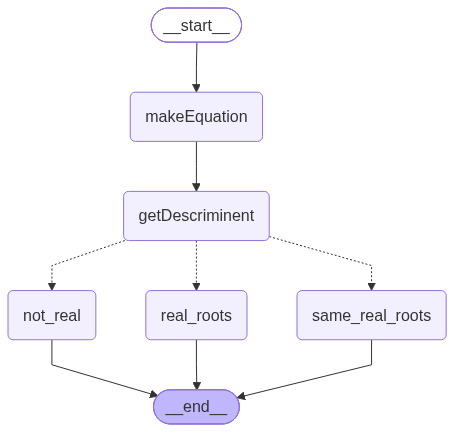

In [ ]:
workflow



In [ ]:
initial_state={
    'a': 1,
    'b': 4,
    'c': 2
}

result=workflow.invoke(initial_state)
print(result)

KeyError: 'discriminant'